<a href="https://colab.research.google.com/github/zmzain/zmzain/blob/main/EDLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, RepeatVector, TimeDistributed, Dense, Flatten, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# -----------------------------
# 1. Load and prepare data
# -----------------------------
df = pd.read_csv("https://raw.githubusercontent.com/zmzain/zmzain/89462097da8cf598cf5e1ddfc2853c4a088f3d49/data1.csv")
texts = df["Text"].astype(str).values
labels = df["class"].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

X_seq = tokenizer.texts_to_sequences(texts)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding="post", truncating="post")
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

X_train_pad, X_test_pad, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42, stratify=y_train
)

classes = np.unique(y_tr)
class_weights_array = compute_class_weight("balanced", classes=classes, y=y_tr)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}


In [5]:
# -----------------------------
# 2. Encoder-Decoder LSTM model builder
# -----------------------------
def build_lstm_model(trial, vocab_size, max_len, num_classes):
    # --- Expanded Search Space ---
    embedding_dim = trial.suggest_categorical("embedding_dim", [100, 200, 300])
    lstm_units    = trial.suggest_int("lstm_units", 128, 512, step=128)
    dropout_rate  = trial.suggest_float("dropout_rate", 0.3, 0.5)
    rec_dropout   = trial.suggest_float("rec_dropout", 0.1, 0.3) # Recurrent dropout
    lr            = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    model = Sequential()

    # 1. Embedding - Using a larger dim
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embedding_dim,
                        input_length=max_len,
                        mask_zero=True)) # Masking ignores padding tokens

    # 2. ENCODER
    # Increased units and added recurrent dropout
    model.add(LSTM(lstm_units,
                   dropout=dropout_rate,
                   recurrent_dropout=rec_dropout))

    # 3. BRIDGE
    model.add(RepeatVector(max_len))

    # 4. DECODER
    model.add(LSTM(lstm_units,
                   return_sequences=True,
                   dropout=dropout_rate,
                   recurrent_dropout=rec_dropout))

    # 5. OUTPUT - Added a more robust head
    model.add(TimeDistributed(Dense(64, activation="relu")))
    model.add(Flatten())
    model.add(Dropout(dropout_rate)) # Extra protection before final layer
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=lr),
        metrics=["accuracy"]
    )
    return model

In [6]:
# -----------------------------
# 3. Optuna objective
# -----------------------------
def objective(trial):
    tf.keras.backend.clear_session()
    model = build_lstm_model(trial, vocab_size, max_len, num_classes)

    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    return f1_score(y_val, y_val_pred, average="macro")


In [7]:
# -----------------------------
# 4. Run Optuna study
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Best Params: {study.best_params}")


[I 2026-05-22 23:29:21,349] A new study created in memory with name: no-name-f817189e-d5d9-4dd9-91e5-ab9ff4e6b40e
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
[I 2026-05-23 00:00:12,304] Trial 0 finished with value: 0.204549727392367 and parameters: {'embedding_dim': 100, 'lstm_units': 512, 'dropout_rate': 0.41517821637417784, 'rec_dropout': 0.2922558761661661, 'lr': 0.0023637618624587063, 'batch_size': 16}. Best is trial 0 with value: 0.204549727392367.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
[I 2026-05-23 00:15:56,287] Trial 1 finished with value: 0.6878722408582189 and parameters: {'embedding_dim': 200, 'lstm_units': 128, 'dropout_rate': 0.38661862139408715, 'rec_dropout': 0.17818111988828528, 'lr': 0.00268498859571564, 'batch_size': 32}. Bes

Best Params: {'embedding_dim': 200, 'lstm_units': 128, 'dropout_rate': 0.4829045476843175, 'rec_dropout': 0.2819548193929755, 'lr': 0.0004741954468990803, 'batch_size': 32}


In [8]:
# -----------------------------
# 5. Train final model
# -----------------------------
tf.keras.backend.clear_session()
best_model = build_lstm_model(
    optuna.trial.FixedTrial(study.best_params),
    vocab_size, max_len, num_classes
)

best_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=study.best_params["batch_size"],
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    class_weight=class_weights,
    verbose=1
)



Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


519/519 ━━━━━━━━━━━━━━━━━━━━ 270s 500ms/step - accuracy: 0.6234 - loss: 0.8482 - val_accuracy: 0.7337 - val_loss: 0.6719
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 257s 495ms/step - accuracy: 0.8082 - loss: 0.4942 - val_accuracy: 0.7630 - val_loss: 0.6029
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 257s 494ms/step - accuracy: 0.8875 - loss: 0.2942 - val_accuracy: 0.7630 - val_loss: 0.7105
Epoch 4/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 257s 494ms/step - accuracy: 0.9328 - loss: 0.1852 - val_accuracy: 0.7516 - val_loss: 0.8424
Epoch 5/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 256s 494ms/step - accuracy: 0.9516 - loss: 0.1337 - val_accuracy: 0.7386 - val_loss: 0.9919
Epoch 6/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 257s 494ms/step - accuracy: 0.9653 - loss: 0.0944 - val_accuracy: 0.7495 - val_loss: 0.9961
Epoch 7/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 256s 494ms/step - accuracy: 0.9741 - loss: 0.0779 - val_accuracy: 0.7419 - val_loss: 1.0623


144/144 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step

Classification Report:
               precision    recall  f1-score   support

    negative       0.78      0.74      0.76      1836
     neutral       0.78      0.80      0.79      2039
    positive       0.60      0.64      0.62       733

    accuracy                           0.75      4608
   macro avg       0.72      0.73      0.72      4608
weighted avg       0.75      0.75      0.75      4608



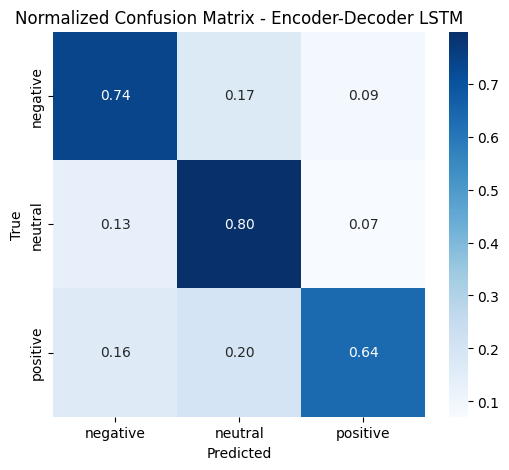

In [9]:
# -----------------------------
# 6. Evaluate
# -----------------------------
y_test_pred = np.argmax(best_model.predict(X_test_pad), axis=1)

print("\nClassification Report:\n", classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Normalized Confusion Matrix - Encoder-Decoder LSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()